In [1]:
import os
import glob
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Python environment ready.")

Python environment ready.


In [2]:
PROJECT_DIR = Path.home() / "esp-projects" / "csi_receiver"
DATA_DIR = PROJECT_DIR / "dataset"

print("Project:", PROJECT_DIR)
print("Dataset:", DATA_DIR)

files = sorted(DATA_DIR.glob("*.csv"))

print(f"\nFound {len(files)} CSV files:")
for f in files:
    print(" ", f.name)

Project: /Users/barnilmahanta/esp-projects/csi_receiver
Dataset: /Users/barnilmahanta/esp-projects/csi_receiver/dataset

Found 15 CSV files:
  empty_01.csv
  empty_02.csv
  empty_03.csv
  empty_04.csv
  empty_05.csv
  moving_01.csv
  moving_02.csv
  moving_03.csv
  moving_04.csv
  moving_05.csv
  standing_01.csv
  standing_02.csv
  standing_03.csv
  standing_04.csv
  standing_05.csv


In [3]:
def get_label(filename):
    if filename.startswith("empty_"):
        return "empty"
    elif filename.startswith("standing_"):
        return "standing"
    elif filename.startswith("moving_"):
        return "moving"
    else:
        return "unknown"


file_info = pd.DataFrame({
    "file": [f.name for f in files],
    "path": [str(f) for f in files],
})

file_info["label"] = file_info["file"].apply(get_label)

print(file_info)
print("\nClass distribution:")
print(file_info["label"].value_counts())

               file                                               path  \
0      empty_01.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
1      empty_02.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
2      empty_03.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
3      empty_04.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
4      empty_05.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
5     moving_01.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
6     moving_02.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
7     moving_03.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
8     moving_04.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
9     moving_05.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
10  standing_01.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
11  standing_02.csv  /Users/barnilmahanta/esp-projects/csi_receiver...   
12  standing_03.csv  /Users/barnilmaha

In [4]:
test_file = DATA_DIR / "empty_01.csv"

df_test = pd.read_csv(test_file)

print("File:", test_file.name)
print("Shape:", df_test.shape)
print("\nColumns:")
print(df_test.columns.tolist())

print("\nFirst 3 rows:")
display(df_test.head(3))

File: empty_01.csv
Shape: (626, 3)

Columns:
['timestamp', 'sample_number', 'csi_data']

First 3 rows:


,timestamp,sample_number,csi_data
0,0.089613,1,"CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,8..."
1,0.190929,2,"CSI,3206,128,83,49,21,0,-26,4,-27,2,-28,4,-28,..."
2,0.296084,3,"CSI,3210,128,83,49,21,0,-29,0,-31,-1,-31,-2,-2..."


In [8]:
import re

def parse_csi_string(csi_string):
    """
    Extract all integer values from a CSI record.
    Non-numeric text such as 'CSI' is ignored.
    """
    return [int(x) for x in re.findall(r"-?\d+", str(csi_string))]


csi_lengths = df_test["csi_data"].apply(
    lambda x: len(parse_csi_string(x))
)

print("CSI numeric-value length distribution:")
print(csi_lengths.value_counts().sort_index())

print("\nMinimum length:", csi_lengths.min())
print("Maximum length:", csi_lengths.max())
print("Most common length:", csi_lengths.mode()[0])

CSI numeric-value length distribution:
csi_data
130    625
390      1
Name: count, dtype: int64

Minimum length: 130
Maximum length: 390
Most common length: 130


In [9]:
print("First CSI record:")
print(df_test["csi_data"].iloc[0])

print("\nParsed numeric values:")
print(parse_csi_string(df_test["csi_data"].iloc[0]))

print("\nNumber of numeric values:",
      len(parse_csi_string(df_test["csi_data"].iloc[0])))

First CSI record:
CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,0,1,-28,0,CSI,3202,128,83,49,21,

In [10]:
EXPECTED_LENGTH = 130

all_length_stats = []

for file in files:
    df = pd.read_csv(file)

    lengths = df["csi_data"].apply(
        lambda x: len(parse_csi_string(x))
    )

    normal = (lengths == EXPECTED_LENGTH).sum()
    abnormal = (lengths != EXPECTED_LENGTH).sum()

    all_length_stats.append({
        "file": file.name,
        "label": get_label(file.name),
        "samples": len(df),
        "normal": normal,
        "abnormal": abnormal,
        "min_length": lengths.min(),
        "max_length": lengths.max()
    })

length_stats = pd.DataFrame(all_length_stats)

display(length_stats)

print("\nTotal samples:", length_stats["samples"].sum())
print("Total normal:", length_stats["normal"].sum())
print("Total abnormal:", length_stats["abnormal"].sum())

,file,label,samples,normal,abnormal,min_length,max_length
0,empty_01.csv,empty,626,625,1,130,390
1,empty_02.csv,empty,467,464,3,114,386
2,empty_03.csv,empty,443,442,1,130,843
3,empty_04.csv,empty,380,379,1,119,130
4,empty_05.csv,empty,1096,1096,0,130,130
5,moving_01.csv,moving,862,862,0,130,130
6,moving_02.csv,moving,1055,1053,2,114,430
7,moving_03.csv,moving,1147,1145,2,69,130
8,moving_04.csv,moving,1070,1070,0,130,130
9,moving_05.csv,moving,961,960,1,118,130



Total samples: 12737
Total normal: 12721
Total abnormal: 16


In [11]:
# Look at one clean CSI record
clean_row = df_test[
    df_test["csi_data"].apply(
        lambda x: len(parse_csi_string(x)) == EXPECTED_LENGTH
    )
].iloc[0]

values = parse_csi_string(clean_row["csi_data"])

print("Total numeric fields:", len(values))

for i, value in enumerate(values):
    print(f"{i:3}: {value}")

Total numeric fields: 130
  0: 3206
  1: 128
  2: 83
  3: 49
  4: 21
  5: 0
  6: -26
  7: 4
  8: -27
  9: 2
 10: -28
 11: 4
 12: -28
 13: 5
 14: -27
 15: 6
 16: -25
 17: 8
 18: -25
 19: 7
 20: -27
 21: 4
 22: -26
 23: 5
 24: -19
 25: 6
 26: -13
 27: 5
 28: -10
 29: 5
 30: -9
 31: 8
 32: -9
 33: 11
 34: -8
 35: 13
 36: -5
 37: 14
 38: -6
 39: 16
 40: -8
 41: 18
 42: -7
 43: 17
 44: -5
 45: 16
 46: -5
 47: 17
 48: -7
 49: 17
 50: -7
 51: 14
 52: -7
 53: 9
 54: -7
 55: 8
 56: -2
 57: 2
 58: 0
 59: 0
 60: 0
 61: 0
 62: 0
 63: 0
 64: 0
 65: 0
 66: 0
 67: 0
 68: 0
 69: 0
 70: 0
 71: 0
 72: 0
 73: 0
 74: 0
 75: 0
 76: 0
 77: -2
 78: 2
 79: -4
 80: 2
 81: -2
 82: 1
 83: -1
 84: 0
 85: -1
 86: -1
 87: 0
 88: -3
 89: 1
 90: -6
 91: 1
 92: -10
 93: 0
 94: -14
 95: -2
 96: -15
 97: -4
 98: -15
 99: -7
100: -14
101: -10
102: -14
103: -11
104: -14
105: -11
106: -13
107: -9
108: -14
109: -10
110: -13
111: -12
112: -9
113: -12
114: -7
115: -11
116: -7
117: -8
118: -10
119: -3
120: -15
121: 0
122: -16


In [12]:
CSI_START = 6
CSI_VALUES = 124
NUM_SUBCARRIERS = CSI_VALUES // 2

def extract_csi_iq(csi_string):
    values = parse_csi_string(csi_string)

    # Reject malformed packets
    if len(values) != 130:
        return None

    # First 6 = metadata
    # Remaining 124 = I/Q pairs
    iq = np.array(values[CSI_START:], dtype=np.float32)

    return iq.reshape(NUM_SUBCARRIERS, 2)


iq = extract_csi_iq(clean_row["csi_data"])

print("I/Q shape:", iq.shape)
print("\nFirst 5 I/Q pairs:")
print(iq[:5])

I/Q shape: (62, 2)

First 5 I/Q pairs:
[[-26.   4.]
 [-27.   2.]
 [-28.   4.]
 [-28.   5.]
 [-27.   6.]]


In [13]:
def iq_to_amplitude(iq):
    I = iq[:, 0]
    Q = iq[:, 1]

    return np.sqrt(I**2 + Q**2)


amplitude = iq_to_amplitude(iq)

print("Amplitude shape:", amplitude.shape)
print("\nFirst 10 amplitudes:")
print(amplitude[:10])

Amplitude shape: (62,)

First 10 amplitudes:
[26.305893 27.073973 28.284271 28.442924 27.658634 26.24881  25.96151
 27.294687 26.476404 19.924858]


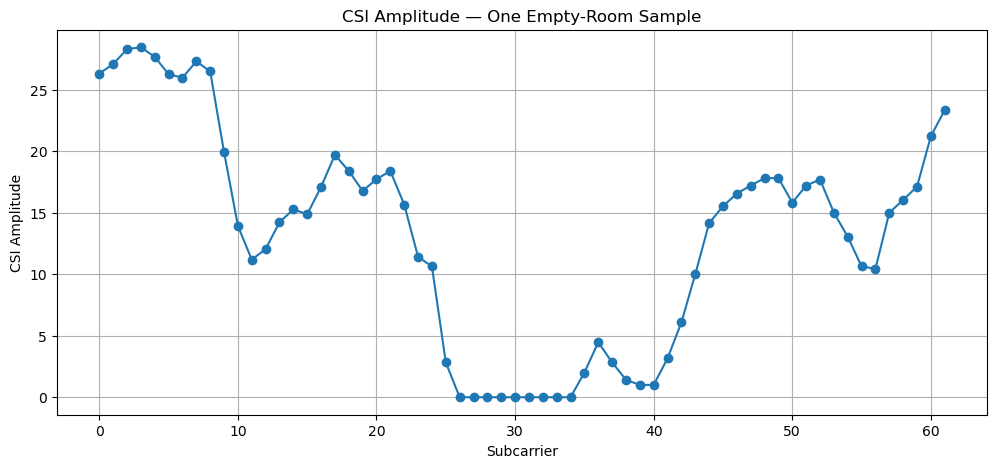

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(amplitude, marker="o")

plt.xlabel("Subcarrier")
plt.ylabel("CSI Amplitude")
plt.title("CSI Amplitude — One Empty-Room Sample")
plt.grid(True)

plt.show()

In [15]:
all_data = []

for file in files:
    df = pd.read_csv(file)

    for _, row in df.iterrows():
        values = parse_csi_string(row["csi_data"])

        # Keep only valid 130-value CSI packets
        if len(values) != 130:
            continue

        iq = np.array(values[6:], dtype=np.float32)
        iq = iq.reshape(62, 2)

        amplitude = np.sqrt(
            iq[:, 0]**2 + iq[:, 1]**2
        )

        all_data.append({
            "file": file.name,
            "label": get_label(file.name),
            "timestamp": row["timestamp"],
            "amplitude": amplitude
        })

print("Clean CSI samples:", len(all_data))
print("Expected:", 12721)

Clean CSI samples: 12721
Expected: 12721


In [16]:
# Convert all CSI amplitudes into a single matrix
X = np.vstack([item["amplitude"] for item in all_data])

y = np.array([item["label"] for item in all_data])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts())

X shape: (12721, 62)
y shape: (12721,)

Class distribution:
moving      5090
standing    4625
empty       3006
Name: count, dtype: int64


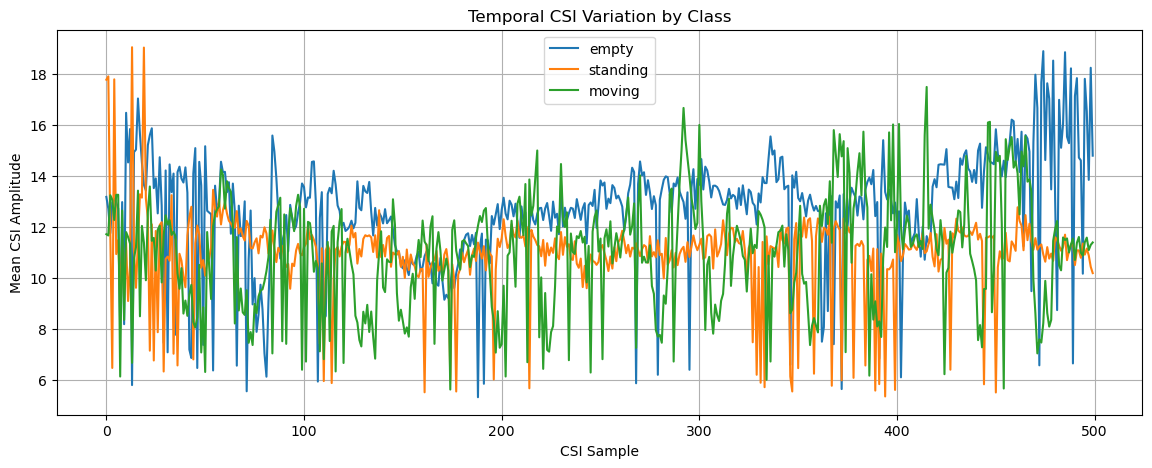

In [17]:
plt.figure(figsize=(14, 5))

for label in ["empty", "standing", "moving"]:
    indices = np.where(y == label)[0]

    # Take the first 500 samples of this class
    indices = indices[:500]

    mean_amplitude = X[indices].mean(axis=1)

    plt.plot(
        mean_amplitude,
        label=label
    )

plt.xlabel("CSI Sample")
plt.ylabel("Mean CSI Amplitude")
plt.title("Temporal CSI Variation by Class")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
variation = []

for label in ["empty", "standing", "moving"]:
    indices = np.where(y == label)[0]

    # Standard deviation across the 62 subcarriers
    # for each CSI packet
    sample_std = X[indices].std(axis=1)

    variation.append({
        "label": label,
        "mean_std": sample_std.mean(),
        "median_std": np.median(sample_std),
        "min_std": sample_std.min(),
        "max_std": sample_std.max()
    })

variation_df = pd.DataFrame(variation)

display(variation_df)

,label,mean_std,median_std,min_std,max_std
0,empty,7.802027,8.207096,3.363718,11.925367
1,standing,7.341306,7.352084,2.718630,21.126188
2,moving,7.450339,7.608760,3.442662,21.129356


In [19]:
# Build a clean dataframe from the 15 recordings

records = []

for item in all_data:
    records.append({
        "file": item["file"],
        "label": item["label"],
        "timestamp": item["timestamp"],
        "amplitude": item["amplitude"]
    })

clean_df = pd.DataFrame(records)

print("Clean dataset:")
print(clean_df.shape)

print("\nRecordings:")
print(
    clean_df.groupby(["label", "file"])
    .size()
    .to_string()
)

Clean dataset:
(12721, 4)

Recordings:
label     file           
empty     empty_01.csv        625
          empty_02.csv        464
          empty_03.csv        442
          empty_04.csv        379
          empty_05.csv       1096
moving    moving_01.csv       862
          moving_02.csv      1053
          moving_03.csv      1145
          moving_04.csv      1070
          moving_05.csv       960
standing  standing_01.csv     764
          standing_02.csv     889
          standing_03.csv     983
          standing_04.csv     943
          standing_05.csv    1046


In [20]:
# Use recordings 01-04 for training
# Use recording 05 for completely unseen testing

train_files = [
    "empty_01.csv", "empty_02.csv", "empty_03.csv", "empty_04.csv",
    "standing_01.csv", "standing_02.csv", "standing_03.csv", "standing_04.csv",
    "moving_01.csv", "moving_02.csv", "moving_03.csv", "moving_04.csv"
]

test_files = [
    "empty_05.csv",
    "standing_05.csv",
    "moving_05.csv"
]

train_df = clean_df[clean_df["file"].isin(train_files)].copy()
test_df = clean_df[clean_df["file"].isin(test_files)].copy()

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nTesting distribution:")
print(test_df["label"].value_counts())

Training samples: 9619
Testing samples: 3102

Training distribution:
label
moving      4130
standing    3579
empty       1910
Name: count, dtype: int64

Testing distribution:
label
empty       1096
standing    1046
moving       960
Name: count, dtype: int64


In [21]:
WINDOW_SIZE = 100
STEP_SIZE = 50

def make_windows(df):
    windows = []
    
    for filename, group in df.groupby("file"):
        # Keep chronological order
        group = group.sort_values("timestamp")
        
        data = np.vstack(group["amplitude"].values)
        label = group["label"].iloc[0]
        
        for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
            window = data[start:start + WINDOW_SIZE]
            
            windows.append({
                "file": filename,
                "label": label,
                "window": window
            })
    
    return windows


train_windows = make_windows(train_df)
test_windows = make_windows(test_df)

print("Training windows:", len(train_windows))
print("Testing windows:", len(test_windows))

print("\nWindow shape:")
print(train_windows[0]["window"].shape)

Training windows: 174
Testing windows: 57

Window shape:
(100, 62)


In [22]:
print("Training windows by class:")
print(
    pd.Series([w["label"] for w in train_windows])
    .value_counts()
)

print("\nTesting windows by class:")
print(
    pd.Series([w["label"] for w in test_windows])
    .value_counts()
)

Training windows by class:
moving      77
standing    65
empty       32
Name: count, dtype: int64

Testing windows by class:
empty       20
standing    19
moving      18
Name: count, dtype: int64


In [23]:
X_train = np.stack([
    w["window"] for w in train_windows
])

y_train = np.array([
    w["label"] for w in train_windows
])

X_test = np.stack([
    w["window"] for w in test_windows
])

y_test = np.array([
    w["label"] for w in test_windows
])

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (174, 100, 62)
y_train: (174,)
X_test: (57, 100, 62)
y_test: (57,)


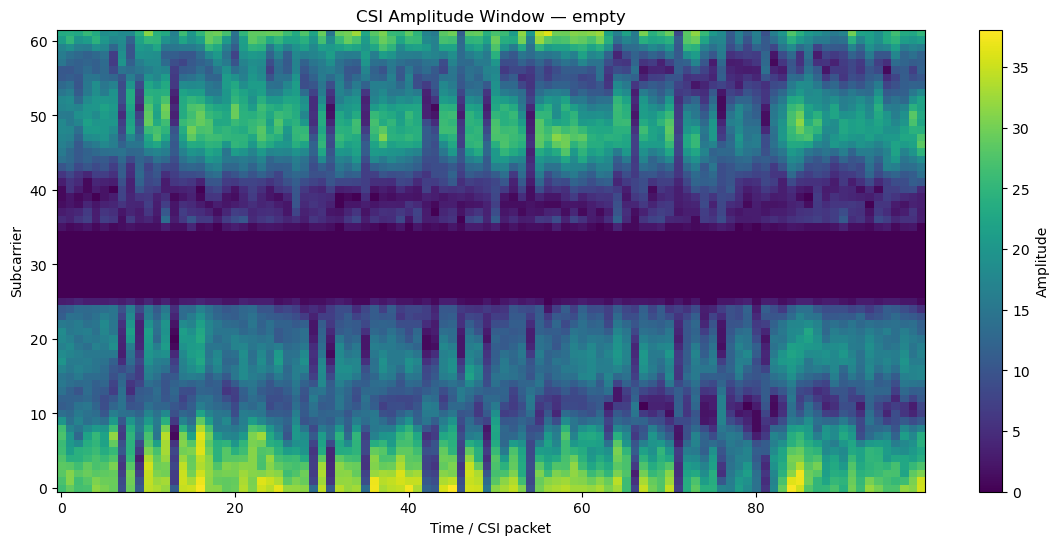

In [24]:
plt.figure(figsize=(14, 6))

plt.imshow(
    X_train[0].T,
    aspect="auto",
    origin="lower"
)

plt.xlabel("Time / CSI packet")
plt.ylabel("Subcarrier")
plt.title(
    f"CSI Amplitude Window — {y_train[0]}"
)

plt.colorbar(label="Amplitude")

plt.show()

In [25]:
# Calculate normalization parameters ONLY from training data

train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True)

# Prevent division by zero
train_std[train_std < 1e-6] = 1.0

X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("Training normalized mean:",
      X_train_norm.mean())

print("Training normalized std:",
      X_train_norm.std())

print("\nShapes:")
print("X_train_norm:", X_train_norm.shape)
print("X_test_norm:", X_test_norm.shape)

Training normalized mean: -3.2148804e-05
Training normalized std: 0.9245748

Shapes:
X_train_norm: (174, 100, 62)
X_test_norm: (57, 100, 62)


In [26]:
X_train_flat = X_train_norm.reshape(
    X_train_norm.shape[0], -1
)

X_test_flat = X_test_norm.reshape(
    X_test_norm.shape[0], -1
)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened testing shape:", X_test_flat.shape)

Flattened training shape: (174, 6200)
Flattened testing shape: (57, 6200)


In [27]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

print("\nEncoded training labels:")
print(y_train_encoded)

Classes: ['empty' 'moving' 'standing']

Encoded training labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train_flat, y_train_encoded)

y_pred = rf.predict(X_test_flat)

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.6491228070175439

Classification Report:
              precision    recall  f1-score   support

       empty       0.63      0.60      0.62        20
      moving       0.59      0.89      0.71        18
    standing       0.82      0.47      0.60        19

    accuracy                           0.65        57
   macro avg       0.68      0.65      0.64        57
weighted avg       0.68      0.65      0.64        57



<Figure size 700x600 with 0 Axes>

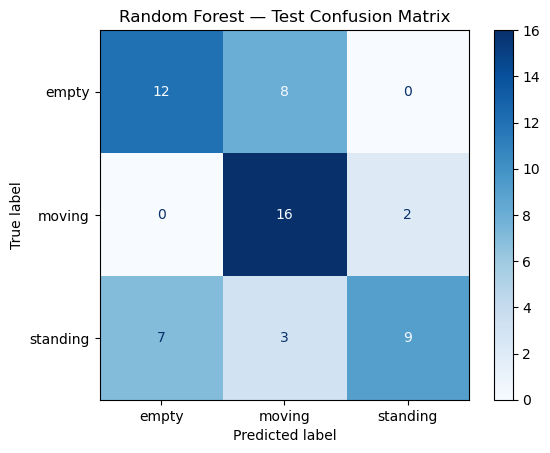

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

plt.title("Random Forest — Test Confusion Matrix")
plt.show()

In [30]:
def extract_features(X):
    features = []

    for window in X:
        # Statistics for each subcarrier across time
        mean = window.mean(axis=0)
        std = window.std(axis=0)
        minimum = window.min(axis=0)
        maximum = window.max(axis=0)
        range_ = maximum - minimum

        # Temporal changes
        diff = np.diff(window, axis=0)

        mean_abs_diff = np.mean(np.abs(diff), axis=0)
        std_diff = np.std(diff, axis=0)

        # Combine everything
        feature_vector = np.concatenate([
            mean,
            std,
            minimum,
            maximum,
            range_,
            mean_abs_diff,
            std_diff
        ])

        features.append(feature_vector)

    return np.array(features)


X_train_features = extract_features(X_train_norm)
X_test_features = extract_features(X_test_norm)

print("Feature matrix:")
print("X_train_features:", X_train_features.shape)
print("X_test_features:", X_test_features.shape)

Feature matrix:
X_train_features: (174, 434)
X_test_features: (57, 434)


In [31]:
rf_features = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_features.fit(
    X_train_features,
    y_train_encoded
)

y_pred_features = rf_features.predict(
    X_test_features
)

print(
    "Feature-based Random Forest accuracy:",
    accuracy_score(y_test_encoded, y_pred_features)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_features,
        target_names=label_encoder.classes_
    )
)

Feature-based Random Forest accuracy: 0.9122807017543859

Classification Report:
              precision    recall  f1-score   support

       empty       0.86      0.90      0.88        20
      moving       1.00      1.00      1.00        18
    standing       0.89      0.84      0.86        19

    accuracy                           0.91        57
   macro avg       0.92      0.91      0.91        57
weighted avg       0.91      0.91      0.91        57



<Figure size 700x600 with 0 Axes>

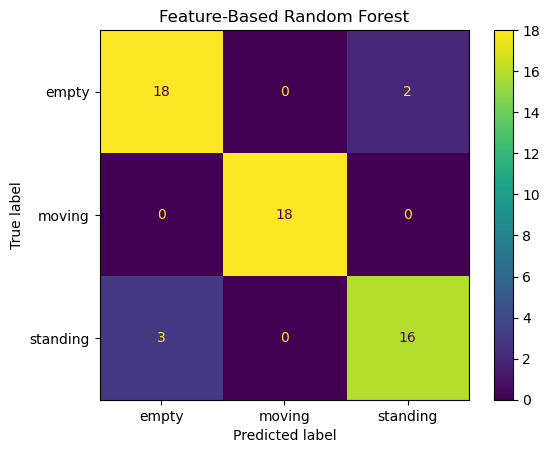

In [32]:
plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred_features,
    display_labels=label_encoder.classes_
)

plt.title("Feature-Based Random Forest")
plt.show()

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_features,
    X_train_features,
    y_train_encoded,
    cv=cv,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross-Validation Scores:
[0.82857143 0.88571429 0.97142857 0.91428571 1.        ]

Mean CV Accuracy: 0.9199999999999999
Standard Deviation: 0.06101187572589319


In [34]:
from sklearn.model_selection import GroupKFold, cross_val_score

# Each window remembers which recording it came from
groups = np.array([
    w["file"] for w in train_windows
])

group_cv = GroupKFold(n_splits=5)

group_scores = cross_val_score(
    rf_features,
    X_train_features,
    y_train_encoded,
    groups=groups,
    cv=group_cv,
    scoring="accuracy"
)

print("Recording-Level Cross-Validation Scores:")
print(group_scores)

print("\nMean Recording-Level Accuracy:", group_scores.mean())
print("Standard Deviation:", group_scores.std())

Recording-Level Cross-Validation Scores:
[0.66666667 0.85294118 0.59459459 0.67647059 0.51515152]

Mean Recording-Level Accuracy: 0.6611649082237319
Standard Deviation: 0.1120662195868267


In [35]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

group_cv = GroupKFold(n_splits=5)

results = []

for fold, (train_idx, val_idx) in enumerate(
    group_cv.split(X_train_features, y_train_encoded, groups=groups),
    start=1
):
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(
        X_train_features[train_idx],
        y_train_encoded[train_idx]
    )

    pred = model.predict(X_train_features[val_idx])

    results.append({
        "fold": fold,
        "accuracy": accuracy_score(
            y_train_encoded[val_idx],
            pred
        ),
        "validation_recordings": sorted(
            set(groups[val_idx])
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

,fold,accuracy,validation_recordings
0,1,0.666667,"[empty_02.csv, empty_03.csv, moving_03.csv]"
1,2,0.852941,"[moving_04.csv, standing_01.csv]"
2,3,0.594595,"[empty_01.csv, empty_04.csv, moving_02.csv]"
3,4,0.676471,"[moving_01.csv, standing_03.csv]"
4,5,0.606061,"[standing_02.csv, standing_04.csv]"


In [36]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score

logo = LeaveOneGroupOut()

recording_results = []

for train_idx, test_idx in logo.split(
    X_train_features,
    y_train_encoded,
    groups=groups
):
    test_recording = groups[test_idx][0]

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(
        X_train_features[train_idx],
        y_train_encoded[train_idx]
    )

    pred = model.predict(X_train_features[test_idx])

    accuracy = accuracy_score(
        y_train_encoded[test_idx],
        pred
    )

    recording_results.append({
        "recording": test_recording,
        "true_class": label_encoder.inverse_transform(
            [y_train_encoded[test_idx][0]]
        )[0],
        "accuracy": accuracy,
        "windows": len(test_idx)
    })

recording_results_df = pd.DataFrame(recording_results)

recording_results_df = recording_results_df.sort_values(
    "accuracy"
)

display(recording_results_df)

,recording,true_class,accuracy,windows
0,empty_01.csv,empty,0.090909,11
2,empty_03.csv,empty,0.285714,7
3,empty_04.csv,empty,0.333333,6
1,empty_02.csv,empty,0.375000,8
11,standing_04.csv,standing,0.470588,17
8,standing_01.csv,standing,0.500000,14
10,standing_03.csv,standing,0.555556,18
9,standing_02.csv,standing,0.625000,16
4,moving_01.csv,moving,0.687500,16
5,moving_02.csv,moving,1.000000,20


In [37]:
# Compare the basic CSI statistics of every recording

recording_stats = []

for filename, group in train_df.groupby("file"):
    data = np.vstack(group["amplitude"].values)

    recording_stats.append({
        "file": filename,
        "label": group["label"].iloc[0],
        "samples": len(data),
        "mean_amplitude": data.mean(),
        "std_amplitude": data.std(),
        "min_amplitude": data.min(),
        "max_amplitude": data.max(),
        "mean_temporal_change": np.abs(np.diff(data, axis=0)).mean()
    })

recording_stats_df = pd.DataFrame(recording_stats)

display(
    recording_stats_df.sort_values(
        ["label", "mean_amplitude"]
    )
)

,file,label,samples,mean_amplitude,std_amplitude,min_amplitude,max_amplitude,mean_temporal_change
3,empty_04.csv,empty,379,10.861921,8.284667,0.0,42.544094,4.176596
2,empty_03.csv,empty,442,11.296882,8.169063,0.0,39.000000,3.618823
1,empty_02.csv,empty,464,11.896330,8.305361,0.0,40.804413,2.895109
0,empty_01.csv,empty,625,13.127581,9.122596,0.0,44.045429,3.313414
4,moving_01.csv,moving,862,10.945513,8.031385,0.0,42.154476,2.870147
5,moving_02.csv,moving,1053,11.539559,8.317109,0.0,63.245552,5.049524
6,moving_03.csv,moving,1145,11.927526,8.464451,0.0,40.311287,5.044467
7,moving_04.csv,moving,1070,12.229446,8.493477,0.0,38.275318,5.040982
11,standing_04.csv,standing,943,10.074910,7.753925,0.0,43.600460,3.011659
10,standing_03.csv,standing,983,10.323465,7.773279,0.0,44.553337,3.651283


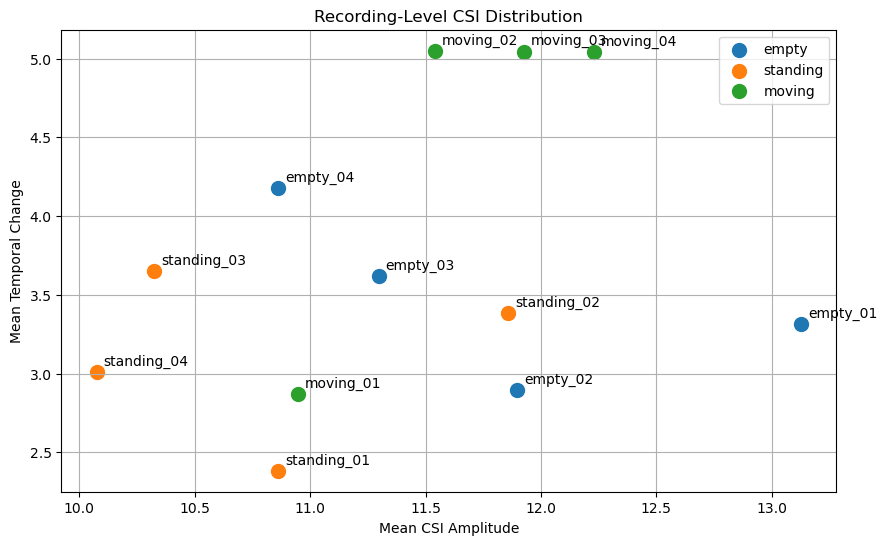

In [38]:
plt.figure(figsize=(10, 6))

for label in ["empty", "standing", "moving"]:
    subset = recording_stats_df[
        recording_stats_df["label"] == label
    ]

    plt.scatter(
        subset["mean_amplitude"],
        subset["mean_temporal_change"],
        s=100,
        label=label
    )

    for _, row in subset.iterrows():
        plt.annotate(
            row["file"].replace(".csv", ""),
            (row["mean_amplitude"], row["mean_temporal_change"]),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.xlabel("Mean CSI Amplitude")
plt.ylabel("Mean Temporal Change")
plt.title("Recording-Level CSI Distribution")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# Feature importance from the trained feature-based Random Forest

feature_importance = rf_features.feature_importances_

importance_df = pd.DataFrame({
    "feature_index": np.arange(len(feature_importance)),
    "importance": feature_importance
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

display(importance_df.head(30))

,feature_index,importance
124,124,0.038088
141,141,0.035151
125,125,0.027711
140,140,0.026235
178,178,0.014683
117,117,0.014219
16,16,0.013907
264,264,0.013135
122,122,0.012519
263,263,0.011959


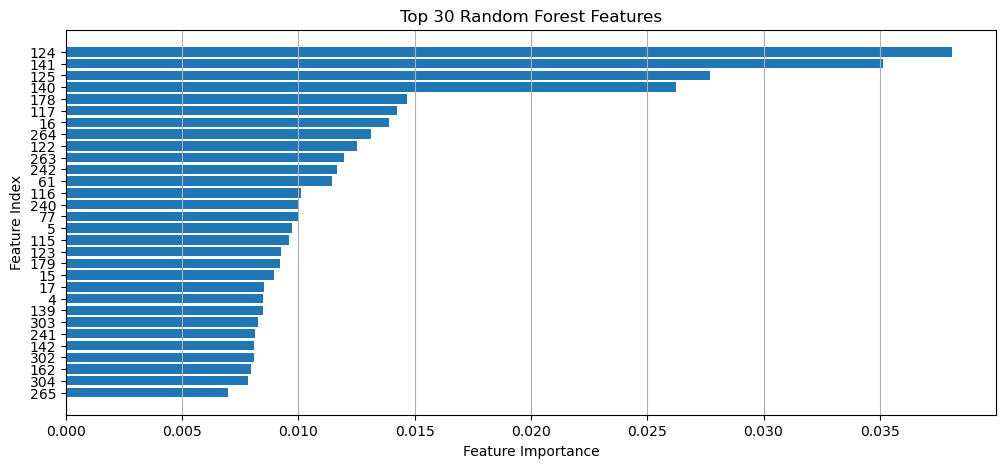

In [40]:
plt.figure(figsize=(12, 5))

top_n = 30
top_features = importance_df.head(top_n).sort_values("importance")

plt.barh(
    top_features["feature_index"].astype(str),
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature Index")
plt.title("Top 30 Random Forest Features")
plt.grid(True, axis="x")

plt.show()

In [41]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

group_cv = GroupKFold(n_splits=5)

proper_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_cv.split(X_train, y_train_encoded, groups=groups),
    start=1
):
    # --------------------------------------------------
    # 1. Fit normalization ONLY on this fold's training data
    # --------------------------------------------------
    fold_mean = X_train[train_idx].mean(
        axis=(0, 1),
        keepdims=True
    )

    fold_std = X_train[train_idx].std(
        axis=(0, 1),
        keepdims=True
    )

    fold_std[fold_std < 1e-6] = 1.0

    X_fold_train = (
        X_train[train_idx] - fold_mean
    ) / fold_std

    X_fold_val = (
        X_train[val_idx] - fold_mean
    ) / fold_std

    # --------------------------------------------------
    # 2. Extract the same 7 statistical features
    # --------------------------------------------------
    X_fold_train_features = extract_features(
        X_fold_train
    )

    X_fold_val_features = extract_features(
        X_fold_val
    )

    # --------------------------------------------------
    # 3. Train Random Forest
    # --------------------------------------------------
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(
        X_fold_train_features,
        y_train_encoded[train_idx]
    )

    # --------------------------------------------------
    # 4. Evaluate on completely unseen recordings
    # --------------------------------------------------
    pred = model.predict(X_fold_val_features)

    accuracy = accuracy_score(
        y_train_encoded[val_idx],
        pred
    )

    proper_cv_results.append({
        "fold": fold,
        "accuracy": accuracy,
        "validation_recordings": sorted(
            set(groups[val_idx])
        )
    })

proper_cv_df = pd.DataFrame(proper_cv_results)

display(proper_cv_df)

print(
    "\nProper recording-level CV accuracy:",
    proper_cv_df["accuracy"].mean()
)

print(
    "Standard deviation:",
    proper_cv_df["accuracy"].std()
)

,fold,accuracy,validation_recordings
0,1,0.666667,"[empty_02.csv, empty_03.csv, moving_03.csv]"
1,2,0.852941,"[moving_04.csv, standing_01.csv]"
2,3,0.594595,"[empty_01.csv, empty_04.csv, moving_02.csv]"
3,4,0.676471,"[moving_01.csv, standing_03.csv]"
4,5,0.606061,"[standing_02.csv, standing_04.csv]"



Proper recording-level CV accuracy: 0.6793467264055499
Standard deviation: 0.10351071014737347


In [42]:
# Temporal-dynamics-only features
X_train_temporal = X_train_features[:, 310:434]
X_test_temporal = X_test_features[:, 310:434]

print("Temporal feature shape:")
print("X_train:", X_train_temporal.shape)
print("X_test :", X_test_temporal.shape)


# --------------------------------------------------
# Recording-level cross-validation
# --------------------------------------------------

temporal_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_cv.split(
        X_train_temporal,
        y_train_encoded,
        groups=groups
    ),
    start=1
):

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(
        X_train_temporal[train_idx],
        y_train_encoded[train_idx]
    )

    pred = model.predict(
        X_train_temporal[val_idx]
    )

    acc = accuracy_score(
        y_train_encoded[val_idx],
        pred
    )

    temporal_results.append({
        "fold": fold,
        "accuracy": acc,
        "validation_recordings": sorted(
            set(groups[val_idx])
        )
    })


temporal_results_df = pd.DataFrame(
    temporal_results
)

display(temporal_results_df)

print(
    "\nTemporal-only recording-level accuracy:",
    temporal_results_df["accuracy"].mean()
)

print(
    "Standard deviation:",
    temporal_results_df["accuracy"].std()
)

Temporal feature shape:
X_train: (174, 124)
X_test : (57, 124)


,fold,accuracy,validation_recordings
0,1,0.611111,"[empty_02.csv, empty_03.csv, moving_03.csv]"
1,2,0.882353,"[moving_04.csv, standing_01.csv]"
2,3,0.540541,"[empty_01.csv, empty_04.csv, moving_02.csv]"
3,4,0.411765,"[moving_01.csv, standing_03.csv]"
4,5,0.393939,"[standing_02.csv, standing_04.csv]"



Temporal-only recording-level accuracy: 0.5679417385299738
Standard deviation: 0.19757081400067456


In [43]:
feature_groups = {
    "mean": (0, 62),
    "std": (62, 124),
    "min": (124, 186),
    "max": (186, 248),
    "range": (248, 310),
    "mean_abs_diff": (310, 372),
    "std_diff": (372, 434),
}

ablation_results = []

for feature_name, (start, end) in feature_groups.items():

    X_group = X_train_features[:, start:end]

    fold_scores = []

    for train_idx, val_idx in group_cv.split(
        X_group,
        y_train_encoded,
        groups=groups
    ):

        model = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

        model.fit(
            X_group[train_idx],
            y_train_encoded[train_idx]
        )

        pred = model.predict(
            X_group[val_idx]
        )

        fold_scores.append(
            accuracy_score(
                y_train_encoded[val_idx],
                pred
            )
        )

    ablation_results.append({
        "feature_group": feature_name,
        "mean_accuracy": np.mean(fold_scores),
        "std_accuracy": np.std(fold_scores),
        "fold_1": fold_scores[0],
        "fold_2": fold_scores[1],
        "fold_3": fold_scores[2],
        "fold_4": fold_scores[3],
        "fold_5": fold_scores[4],
    })


ablation_df = pd.DataFrame(ablation_results)

ablation_df = ablation_df.sort_values(
    "mean_accuracy",
    ascending=False
)

display(ablation_df)

,feature_group,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
1,std,0.691263,0.116319,0.750000,0.882353,0.540541,0.647059,0.636364
4,range,0.623796,0.166403,0.555556,0.911765,0.513514,0.441176,0.696970
3,max,0.575790,0.120722,0.611111,0.794118,0.459459,0.529412,0.484848
0,mean,0.559573,0.120641,0.611111,0.588235,0.378378,0.735294,0.484848
5,mean_abs_diff,0.549489,0.167782,0.583333,0.823529,0.594595,0.382353,0.363636
2,min,0.531664,0.156568,0.583333,0.764706,0.594595,0.382353,0.333333
6,std_diff,0.528044,0.175514,0.527778,0.852941,0.513514,0.382353,0.363636


In [44]:
# STD + Range features
#
# STD   = features 62:124
# Range = features 248:310

X_train_std_range = np.concatenate(
    [
        X_train_features[:, 62:124],
        X_train_features[:, 248:310]
    ],
    axis=1
)

X_test_std_range = np.concatenate(
    [
        X_test_features[:, 62:124],
        X_test_features[:, 248:310]
    ],
    axis=1
)

print("STD + Range shape:")
print("X_train:", X_train_std_range.shape)
print("X_test :", X_test_std_range.shape)


std_range_scores = []

for train_idx, val_idx in group_cv.split(
    X_train_std_range,
    y_train_encoded,
    groups=groups
):

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(
        X_train_std_range[train_idx],
        y_train_encoded[train_idx]
    )

    pred = model.predict(
        X_train_std_range[val_idx]
    )

    std_range_scores.append(
        accuracy_score(
            y_train_encoded[val_idx],
            pred
        )
    )


print("\nSTD + Range recording-level CV:")
print(std_range_scores)

print(
    "\nMean accuracy:",
    np.mean(std_range_scores)
)

print(
    "Standard deviation:",
    np.std(std_range_scores)
)

STD + Range shape:
X_train: (174, 124)
X_test : (57, 124)

STD + Range recording-level CV:
[0.6111111111111112, 0.9411764705882353, 0.5135135135135135, 0.5588235294117647, 0.6666666666666666]

Mean accuracy: 0.6582582582582582
Standard deviation: 0.15044904527185562


In [45]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

models = {
    "SVM RBF": make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale"
        )
    ),

    "SVM Linear": make_pipeline(
        StandardScaler(),
        SVC(
            kernel="linear",
            C=1.0
        )
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight="balanced"
        )
    ),

    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(
            n_neighbors=5
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=42
    )
}


# -----------------------------------------
# Compare algorithms using STD features
# -----------------------------------------

X = X_train_features[:, 62:124]

algorithm_results = []

for name, model in models.items():

    scores = []

    for train_idx, val_idx in group_cv.split(
        X,
        y_train_encoded,
        groups=groups
    ):

        model.fit(
            X[train_idx],
            y_train_encoded[train_idx]
        )

        pred = model.predict(
            X[val_idx]
        )

        scores.append(
            accuracy_score(
                y_train_encoded[val_idx],
                pred
            )
        )

    algorithm_results.append({
        "model": name,
        "mean_accuracy": np.mean(scores),
        "std_accuracy": np.std(scores),
        "fold_1": scores[0],
        "fold_2": scores[1],
        "fold_3": scores[2],
        "fold_4": scores[3],
        "fold_5": scores[4]
    })


algorithm_df = pd.DataFrame(
    algorithm_results
).sort_values(
    "mean_accuracy",
    ascending=False
)

display(algorithm_df)

,model,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
0,SVM RBF,0.708935,0.119149,0.611111,0.882353,0.621622,0.823529,0.606061
4,Random Forest,0.691263,0.116319,0.750000,0.882353,0.540541,0.647059,0.636364
6,HistGradientBoosting,0.654599,0.130405,0.694444,0.852941,0.594595,0.676471,0.454545
3,KNN,0.653261,0.158341,0.722222,0.823529,0.621622,0.735294,0.363636
5,Extra Trees,0.648987,0.167254,0.722222,0.882353,0.540541,0.705882,0.393939
2,Logistic Regression,0.628302,0.132013,0.777778,0.705882,0.675676,0.588235,0.393939
1,SVM Linear,0.595416,0.139859,0.583333,0.735294,0.648649,0.676471,0.333333


In [46]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

feature_sets = {
    "mean": X_train_features[:, 0:62],

    "std": X_train_features[:, 62:124],

    "min": X_train_features[:, 124:186],

    "max": X_train_features[:, 186:248],

    "range": X_train_features[:, 248:310],

    "mean_abs_diff": X_train_features[:, 310:372],

    "std_diff": X_train_features[:, 372:434],

    "mean + std": np.concatenate([
        X_train_features[:, 0:62],
        X_train_features[:, 62:124]
    ], axis=1),

    "std + range": np.concatenate([
        X_train_features[:, 62:124],
        X_train_features[:, 248:310]
    ], axis=1),

    "std + max": np.concatenate([
        X_train_features[:, 62:124],
        X_train_features[:, 186:248]
    ], axis=1),

    "std + mean_abs_diff": np.concatenate([
        X_train_features[:, 62:124],
        X_train_features[:, 310:372]
    ], axis=1),

    "std + range + max": np.concatenate([
        X_train_features[:, 62:124],
        X_train_features[:, 186:248],
        X_train_features[:, 248:310]
    ], axis=1),

    "all features": X_train_features
}


svm_feature_results = []

for feature_name, X in feature_sets.items():

    scores = []

    for train_idx, val_idx in group_cv.split(
        X,
        y_train_encoded,
        groups=groups
    ):

        svm = make_pipeline(
            StandardScaler(),
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale"
            )
        )

        svm.fit(
            X[train_idx],
            y_train_encoded[train_idx]
        )

        pred = svm.predict(
            X[val_idx]
        )

        scores.append(
            accuracy_score(
                y_train_encoded[val_idx],
                pred
            )
        )

    svm_feature_results.append({
        "feature_set": feature_name,
        "mean_accuracy": np.mean(scores),
        "std_accuracy": np.std(scores),
        "fold_1": scores[0],
        "fold_2": scores[1],
        "fold_3": scores[2],
        "fold_4": scores[3],
        "fold_5": scores[4]
    })


svm_feature_df = pd.DataFrame(
    svm_feature_results
).sort_values(
    "mean_accuracy",
    ascending=False
)

display(svm_feature_df)

,feature_set,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
1,std,0.708935,0.119149,0.611111,0.882353,0.621622,0.823529,0.606061
7,mean + std,0.703205,0.095588,0.694444,0.823529,0.567568,0.794118,0.636364
10,std + mean_abs_diff,0.654924,0.151278,0.611111,0.882353,0.621622,0.735294,0.424242
8,std + range,0.645454,0.119553,0.638889,0.852941,0.513514,0.676471,0.545455
12,all features,0.644087,0.151437,0.694444,0.823529,0.513514,0.764706,0.424242
0,mean,0.626793,0.151130,0.583333,0.676471,0.567568,0.882353,0.424242
9,std + max,0.620677,0.183887,0.638889,0.852941,0.513514,0.764706,0.333333
11,std + range + max,0.598486,0.147091,0.611111,0.852941,0.486486,0.617647,0.424242
5,mean_abs_diff,0.557157,0.171454,0.527778,0.882353,0.540541,0.441176,0.393939
4,range,0.552914,0.140778,0.555556,0.823529,0.459459,0.441176,0.484848


In [47]:
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Best feature representation so far
X = X_train_features[:, 62:124]   # STD features

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

tuning_results = []

for params in ParameterGrid(param_grid):

    scores = []

    for train_idx, val_idx in group_cv.split(
        X,
        y_train_encoded,
        groups=groups
    ):

        model = make_pipeline(
            StandardScaler(),
            SVC(
                kernel="rbf",
                C=params["C"],
                gamma=params["gamma"]
            )
        )

        model.fit(
            X[train_idx],
            y_train_encoded[train_idx]
        )

        pred = model.predict(
            X[val_idx]
        )

        scores.append(
            accuracy_score(
                y_train_encoded[val_idx],
                pred
            )
        )

    tuning_results.append({
        "C": params["C"],
        "gamma": params["gamma"],
        "mean_accuracy": np.mean(scores),
        "std_accuracy": np.std(scores),
        "fold_1": scores[0],
        "fold_2": scores[1],
        "fold_3": scores[2],
        "fold_4": scores[3],
        "fold_5": scores[4]
    })


svm_tuning_df = pd.DataFrame(
    tuning_results
).sort_values(
    "mean_accuracy",
    ascending=False
)

display(svm_tuning_df.head(10))

,C,gamma,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
21,100.0,0.001,0.711012,0.140379,0.777778,0.794118,0.675676,0.852941,0.454545
10,1.0,scale,0.708935,0.119149,0.611111,0.882353,0.621622,0.823529,0.606061
22,100.0,0.01,0.706466,0.114107,0.694444,0.823529,0.675676,0.823529,0.515152
17,10.0,0.01,0.687928,0.178783,0.694444,0.852941,0.675676,0.852941,0.363636
20,100.0,scale,0.684368,0.119721,0.694444,0.852941,0.594595,0.764706,0.515152
12,1.0,0.01,0.680299,0.123592,0.611111,0.882353,0.567568,0.764706,0.575758
16,10.0,0.001,0.660305,0.147284,0.750000,0.882353,0.567568,0.647059,0.454545
15,10.0,scale,0.654391,0.174586,0.666667,0.882353,0.594595,0.764706,0.363636
5,0.1,scale,0.603384,0.160904,0.583333,0.852941,0.540541,0.676471,0.363636
11,1.0,0.001,0.598157,0.161392,0.583333,0.882353,0.513514,0.617647,0.393939


In [48]:
def normalize_each_window(X):
    """
    Normalize each CSI window independently.

    X shape:
        (samples, 100 packets, 62 subcarriers)
    """

    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True)

    std[std < 1e-6] = 1.0

    return (X - mean) / std


# --------------------------------------------------
# Per-window normalized data
# --------------------------------------------------

X_train_window_norm = normalize_each_window(X_train)
X_test_window_norm = normalize_each_window(X_test)

print("Shape:")
print(X_train_window_norm.shape)
print(X_test_window_norm.shape)


# --------------------------------------------------
# Extract STD features
# --------------------------------------------------

X_train_window_std = X_train_window_norm.std(axis=1)
X_test_window_std = X_test_window_norm.std(axis=1)

print("\nSTD feature shape:")
print(X_train_window_std.shape)
print(X_test_window_std.shape)


# --------------------------------------------------
# Recording-level GroupKFold
# --------------------------------------------------

window_norm_scores = []

for train_idx, val_idx in group_cv.split(
    X_train_window_std,
    y_train_encoded,
    groups=groups
):

    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=100,
            gamma=0.001
        )
    )

    model.fit(
        X_train_window_std[train_idx],
        y_train_encoded[train_idx]
    )

    pred = model.predict(
        X_train_window_std[val_idx]
    )

    window_norm_scores.append(
        accuracy_score(
            y_train_encoded[val_idx],
            pred
        )
    )


print("\nPer-window normalized STD:")
print(window_norm_scores)

print(
    "\nMean accuracy:",
    np.mean(window_norm_scores)
)

print(
    "Standard deviation:",
    np.std(window_norm_scores)
)

Shape:
(174, 100, 62)
(57, 100, 62)

STD feature shape:
(174, 62)
(57, 62)

Per-window normalized STD:
[0.75, 0.8823529411764706, 0.6756756756756757, 0.6176470588235294, 0.6666666666666666]

Mean accuracy: 0.7184684684684685
Standard deviation: 0.09223010821116553


In [50]:
# Per-window STD across the 100 time samples
X_train_std = X_train_norm.std(axis=1)
X_test_std = X_test_norm.std(axis=1)

print("STD feature shape:")
print("X_train:", X_train_std.shape)
print("X_test :", X_test_std.shape)

STD feature shape:
X_train: (174, 62)
X_test : (57, 62)


In [51]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score

models = {
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ]),

    "SVM Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", C=1.0))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        random_state=42
    )
}


group_cv = GroupKFold(n_splits=5)

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_std,
        y_train_encoded,
        groups=groups,
        cv=group_cv,
        scoring="accuracy"
    )

    results.append({
        "model": name,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std(),
        "fold_1": scores[0],
        "fold_2": scores[1],
        "fold_3": scores[2],
        "fold_4": scores[3],
        "fold_5": scores[4]
    })

results_df = pd.DataFrame(results).sort_values(
    "mean_accuracy",
    ascending=False
)

display(results_df)

,model,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
0,SVM RBF,0.708935,0.119149,0.611111,0.882353,0.621622,0.823529,0.606061
4,Random Forest,0.684846,0.129577,0.750000,0.882353,0.540541,0.705882,0.545455
6,HistGradientBoosting,0.660005,0.137462,0.694444,0.882353,0.621622,0.647059,0.454545
5,Extra Trees,0.659770,0.178653,0.750000,0.882353,0.567568,0.735294,0.363636
3,KNN,0.653261,0.158341,0.722222,0.823529,0.621622,0.735294,0.363636
2,Logistic Regression,0.647052,0.152747,0.750000,0.794118,0.621622,0.705882,0.363636
1,SVM Linear,0.595416,0.139859,0.583333,0.735294,0.648649,0.676471,0.333333


In [52]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 30, 100, 300],
    "svm__gamma": ["scale", 0.0001, 0.001, 0.01, 0.1]
}

group_cv = GroupKFold(n_splits=5)

grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=group_cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(
    X_train_std,
    y_train_encoded,
    groups=groups
)

print("Best parameters:")
print(grid.best_params_)

print("\nBest recording-level CV accuracy:")
print(grid.best_score_)

Best parameters:
{'svm__C': 100, 'svm__gamma': 0.001}

Best recording-level CV accuracy:
0.711011546305664


In [53]:
svm_tuning_df = pd.DataFrame(grid.cv_results_)

svm_tuning_df = svm_tuning_df.sort_values(
    "mean_test_score",
    ascending=False
)

display(
    svm_tuning_df[
        [
            "param_svm__C",
            "param_svm__gamma",
            "mean_test_score",
            "std_test_score"
        ]
    ].head(15)
)

,param_svm__C,param_svm__gamma,mean_test_score,std_test_score
22,100.0,0.001,0.711012,0.140379
5,1.0,scale,0.708935,0.119149
28,300.0,0.01,0.706466,0.114107
23,100.0,0.01,0.706466,0.114107
17,30.0,0.001,0.706411,0.145449
18,30.0,0.01,0.700227,0.141082
26,300.0,0.0001,0.688081,0.157268
13,10.0,0.01,0.687928,0.178783
25,300.0,scale,0.684368,0.119721
20,100.0,scale,0.684368,0.119721


In [54]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold, cross_val_score

pca_svm_results = []

for n_components in [5, 10, 15, 20, 25, 30, 40, 50]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("svm", SVC(
            kernel="rbf",
            C=100,
            gamma=0.001
        ))
    ])

    scores = cross_val_score(
        model,
        X_train_std,
        y_train_encoded,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring="accuracy",
        n_jobs=-1
    )

    pca_svm_results.append({
        "n_components": n_components,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std(),
        "fold_1": scores[0],
        "fold_2": scores[1],
        "fold_3": scores[2],
        "fold_4": scores[3],
        "fold_5": scores[4]
    })

pca_svm_df = pd.DataFrame(pca_svm_results)

display(
    pca_svm_df.sort_values(
        "mean_accuracy",
        ascending=False
    )
)

,n_components,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
1,10,0.722775,0.168633,0.722222,0.852941,0.702703,0.911765,0.424242
4,25,0.716716,0.160043,0.777778,0.852941,0.675676,0.852941,0.424242
5,30,0.711012,0.140379,0.777778,0.794118,0.675676,0.852941,0.454545
6,40,0.711012,0.140379,0.777778,0.794118,0.675676,0.852941,0.454545
7,50,0.711012,0.140379,0.777778,0.794118,0.675676,0.852941,0.454545
3,20,0.699217,0.164567,0.750000,0.823529,0.675676,0.852941,0.393939
2,15,0.693335,0.160494,0.750000,0.794118,0.675676,0.852941,0.393939
0,5,0.660808,0.129797,0.666667,0.823529,0.594595,0.764706,0.454545


In [55]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, GroupKFold

pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "svm__C": [1, 10, 30, 100, 300, 1000],
    "svm__gamma": ["scale", 0.0001, 0.001, 0.01, 0.1, 1]
}

group_cv = GroupKFold(n_splits=5)

grid_pca = GridSearchCV(
    pca_svm,
    param_grid,
    cv=group_cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_pca.fit(
    X_train_std,
    y_train_encoded,
    groups=groups
)

print("Best parameters:")
print(grid_pca.best_params_)

print("\nBest PCA-SVM CV accuracy:")
print(grid_pca.best_score_)

Best parameters:
{'svm__C': 100, 'svm__gamma': 0.001}

Best PCA-SVM CV accuracy:
0.7227746463040581


In [56]:
pca_tuning_df = pd.DataFrame(grid_pca.cv_results_)

display(
    pca_tuning_df[
        [
            "param_svm__C",
            "param_svm__gamma",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(15)
)

,param_svm__C,param_svm__gamma,mean_test_score,std_test_score
20,100,0.001,0.722775,0.168633
31,1000,0.0001,0.710001,0.169583
0,1,scale,0.696992,0.119621
14,30,0.001,0.694112,0.177687
25,300,0.0001,0.693487,0.154400
30,1000,scale,0.689801,0.096497
24,300,scale,0.689801,0.096497
18,100,scale,0.689801,0.096497
26,300,0.001,0.687956,0.165031
27,300,0.01,0.685378,0.103276


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Final selected model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("svm", SVC(
        kernel="rbf",
        C=100,
        gamma=0.001
    ))
])

# Train on ALL training recordings
final_model.fit(
    X_train_std,
    y_train_encoded
)

# ONE final evaluation on the untouched test set
y_test_pred = final_model.predict(X_test_std)

print("Final Test Accuracy:")
print(accuracy_score(y_test_encoded, y_test_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

Final Test Accuracy:
0.5789473684210527

Classification Report:
              precision    recall  f1-score   support

       empty       0.42      0.40      0.41        20
      moving       0.95      1.00      0.97        18
    standing       0.37      0.37      0.37        19

    accuracy                           0.58        57
   macro avg       0.58      0.59      0.58        57
weighted avg       0.57      0.58      0.57        57



<Figure size 700x600 with 0 Axes>

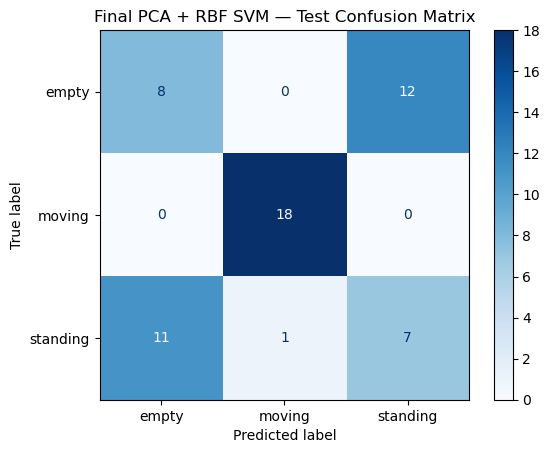

In [58]:
plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_test_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

plt.title("Final PCA + RBF SVM — Test Confusion Matrix")
plt.show()

In [59]:
test_recording_results = []

for recording in np.unique(
    np.array([w["file"] for w in test_windows])
):

    indices = [
        i for i, w in enumerate(test_windows)
        if w["file"] == recording
    ]

    true_label = y_test_encoded[indices[0]]
    predictions = y_test_pred[indices]

    accuracy = np.mean(predictions == true_label)

    test_recording_results.append({
        "recording": recording,
        "true_class": label_encoder.inverse_transform([true_label])[0],
        "windows": len(indices),
        "accuracy": accuracy
    })

test_recording_results_df = pd.DataFrame(
    test_recording_results
).sort_values("accuracy")

display(test_recording_results_df)

print(
    "\nMean recording accuracy:",
    test_recording_results_df["accuracy"].mean()
)

,recording,true_class,windows,accuracy
2,standing_05.csv,standing,19,0.368421
0,empty_05.csv,empty,20,0.400000
1,moving_05.csv,moving,18,1.000000



Mean recording accuracy: 0.5894736842105263


In [60]:
from scipy.stats import mode

recording_vote_results = []

for recording in np.unique(
    np.array([w["file"] for w in test_windows])
):

    indices = [
        i for i, w in enumerate(test_windows)
        if w["file"] == recording
    ]

    true_label = y_test_encoded[indices[0]]

    predicted_labels = y_test_pred[indices]

    majority_prediction = mode(
        predicted_labels,
        keepdims=True
    ).mode[0]

    recording_vote_results.append({
        "recording": recording,
        "true_class": label_encoder.inverse_transform([true_label])[0],
        "predicted_class": label_encoder.inverse_transform(
            [majority_prediction]
        )[0],
        "correct": majority_prediction == true_label,
        "windows": len(indices)
    })

vote_df = pd.DataFrame(recording_vote_results)

display(vote_df)

print(
    "\nRecording majority-vote accuracy:",
    vote_df["correct"].mean()
)

,recording,true_class,predicted_class,correct,windows
0,empty_05.csv,empty,standing,False,20
1,moving_05.csv,moving,moving,True,18
2,standing_05.csv,standing,empty,False,19



Recording majority-vote accuracy: 0.3333333333333333


In [61]:
# Recording-level evaluation using mean SVM decision scores

from scipy.stats import mode
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Get decision scores for every test window
decision_scores = final_model.decision_function(X_test_std)

# Map each window back to its recording
test_groups = np.array([w["file"] for w in test_windows])

recording_results = []

for recording in sorted(np.unique(test_groups)):
    
    indices = np.where(test_groups == recording)[0]
    
    true_label = y_test_encoded[indices[0]]
    
    # Average decision score across all windows
    mean_score = decision_scores[indices].mean(axis=0)
    
    predicted_label = np.argmax(mean_score)
    
    recording_results.append({
        "recording": recording,
        "true_class": label_encoder.inverse_transform([true_label])[0],
        "predicted_class": label_encoder.inverse_transform([predicted_label])[0],
        "correct": predicted_label == true_label,
        "windows": len(indices)
    })

recording_score_df = pd.DataFrame(recording_results)

display(recording_score_df)

print(
    "\nMean decision-score recording accuracy:",
    recording_score_df["correct"].mean()
)

,recording,true_class,predicted_class,correct,windows
0,empty_05.csv,empty,empty,True,20
1,moving_05.csv,moving,moving,True,18
2,standing_05.csv,standing,empty,False,19



Mean decision-score recording accuracy: 0.6666666666666666


Recording-Level Confusion Matrix:
[[1 0 0]
 [0 1 0]
 [1 0 0]]

Recording-Level Accuracy: 0.6666666666666666


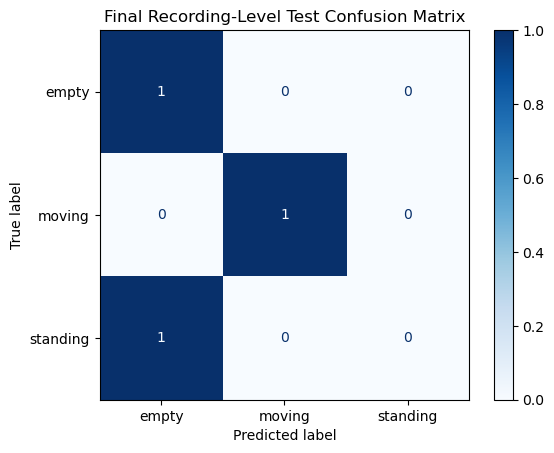

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true_recording = recording_score_df["true_class"]
y_pred_recording = recording_score_df["predicted_class"]

cm = confusion_matrix(
    y_true_recording,
    y_pred_recording,
    labels=label_encoder.classes_
)

print("Recording-Level Confusion Matrix:")
print(cm)

print("\nRecording-Level Accuracy:",
      accuracy_score(y_true_recording, y_pred_recording))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Final Recording-Level Test Confusion Matrix")
plt.show()

In [63]:
from sklearn.metrics import classification_report

print("Final Recording-Level Classification Report:\n")

print(
    classification_report(
        y_true_recording,
        y_pred_recording,
        labels=label_encoder.classes_,
        zero_division=0
    )
)

Final Recording-Level Classification Report:

              precision    recall  f1-score   support

       empty       0.50      1.00      0.67         1
      moving       1.00      1.00      1.00         1
    standing       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



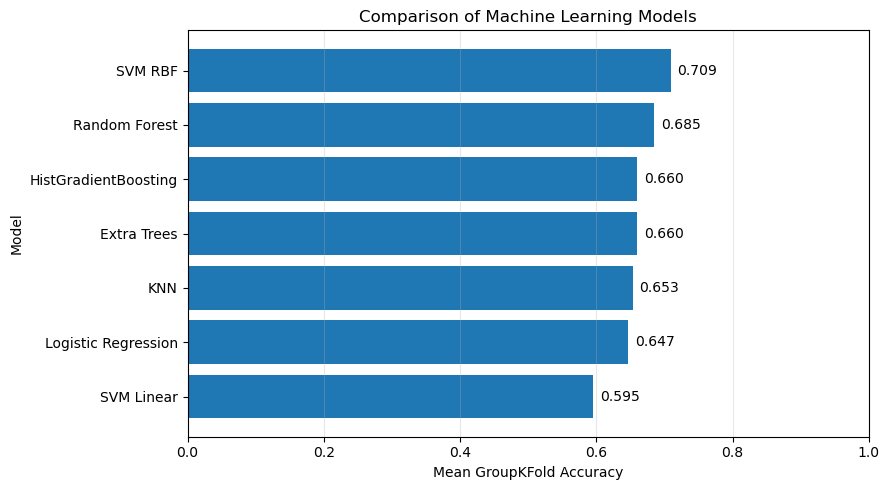

In [64]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 5))

plot_df = results_df.sort_values("mean_accuracy", ascending=True)

plt.barh(
    plot_df["model"],
    plot_df["mean_accuracy"]
)

plt.xlabel("Mean GroupKFold Accuracy")
plt.ylabel("Model")
plt.title("Comparison of Machine Learning Models")

plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)

for i, v in enumerate(plot_df["mean_accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig("figure_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

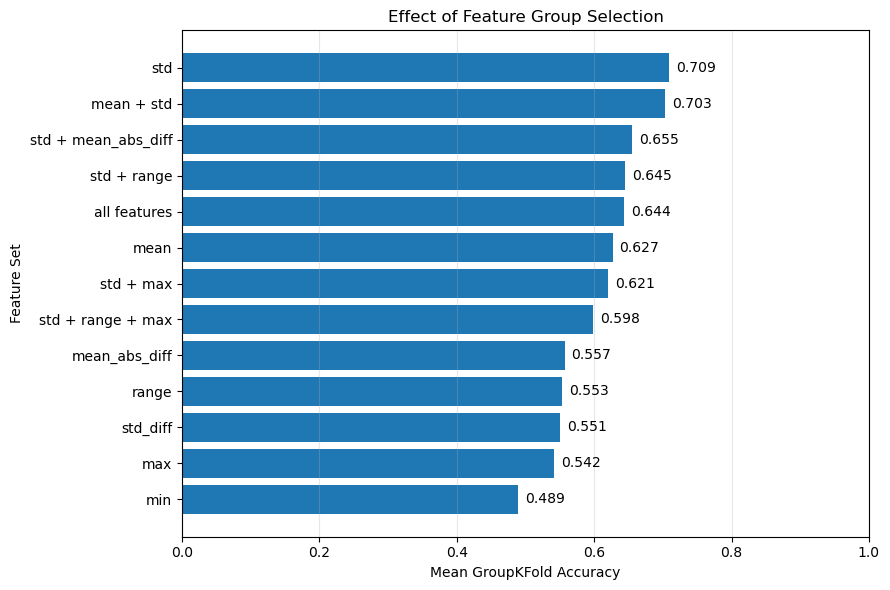

In [65]:
plt.figure(figsize=(9, 6))

plot_df = svm_feature_df.sort_values(
    "mean_accuracy",
    ascending=True
)

plt.barh(
    plot_df["feature_set"],
    plot_df["mean_accuracy"]
)

plt.xlabel("Mean GroupKFold Accuracy")
plt.ylabel("Feature Set")
plt.title("Effect of Feature Group Selection")

plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)

for i, v in enumerate(plot_df["mean_accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig("figure_feature_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

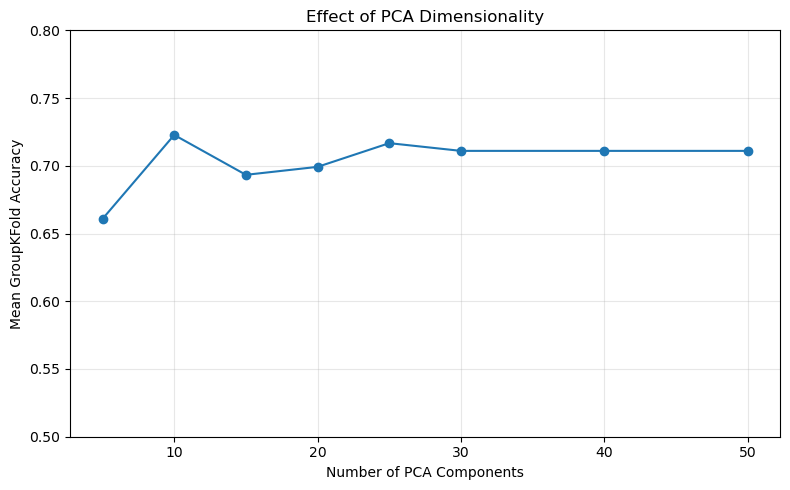

In [66]:
plt.figure(figsize=(8, 5))

plot_df = pca_svm_df.sort_values("n_components")

plt.plot(
    plot_df["n_components"],
    plot_df["mean_accuracy"],
    marker="o"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Mean GroupKFold Accuracy")
plt.title("Effect of PCA Dimensionality")

plt.ylim(0.5, 0.8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figure_pca_components.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/zn/zb9mhw5n21v3xtpd0wv_l1vh0000gn/T/ipykernel_3844/2476810052.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  svm_tuning_df["param_svm__gamma"].replace("scale", 1.0).astype(float)


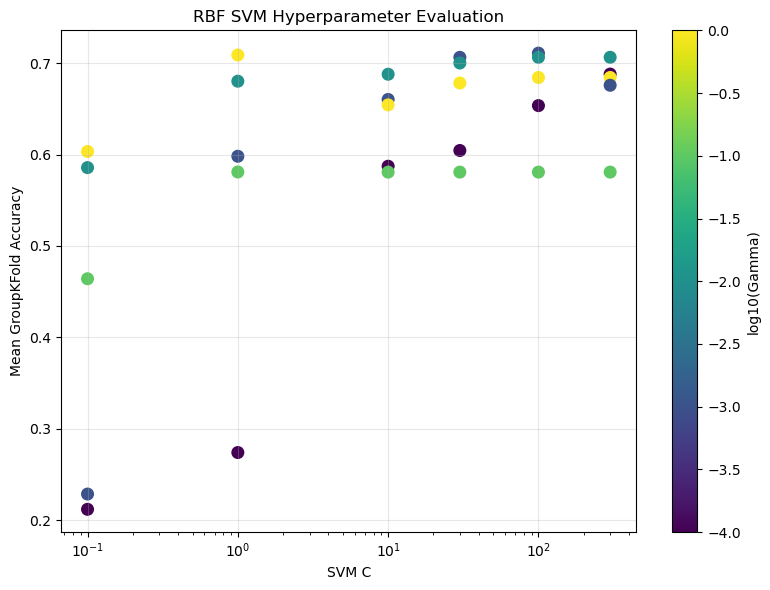

In [67]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    svm_tuning_df["param_svm__C"],
    svm_tuning_df["mean_test_score"],
    c=np.log10(
        svm_tuning_df["param_svm__gamma"].replace("scale", 1.0).astype(float)
    ),
    s=70
)

plt.xscale("log")

plt.xlabel("SVM C")
plt.ylabel("Mean GroupKFold Accuracy")
plt.title("RBF SVM Hyperparameter Evaluation")

plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="log10(Gamma)")

plt.tight_layout()
plt.savefig("figure_svm_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

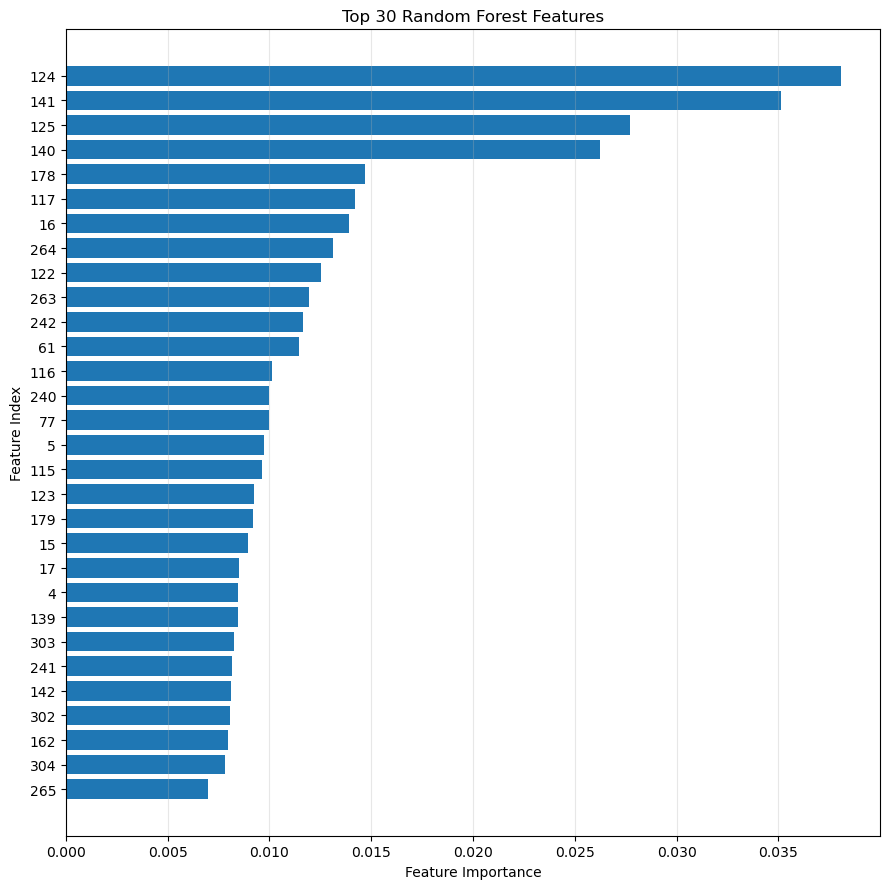

In [68]:
plt.figure(figsize=(9, 9))

top_features = top_features.sort_values("importance", ascending=True)

plt.barh(
    top_features["feature_index"].astype(str),
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature Index")
plt.title("Top 30 Random Forest Features")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("figure_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

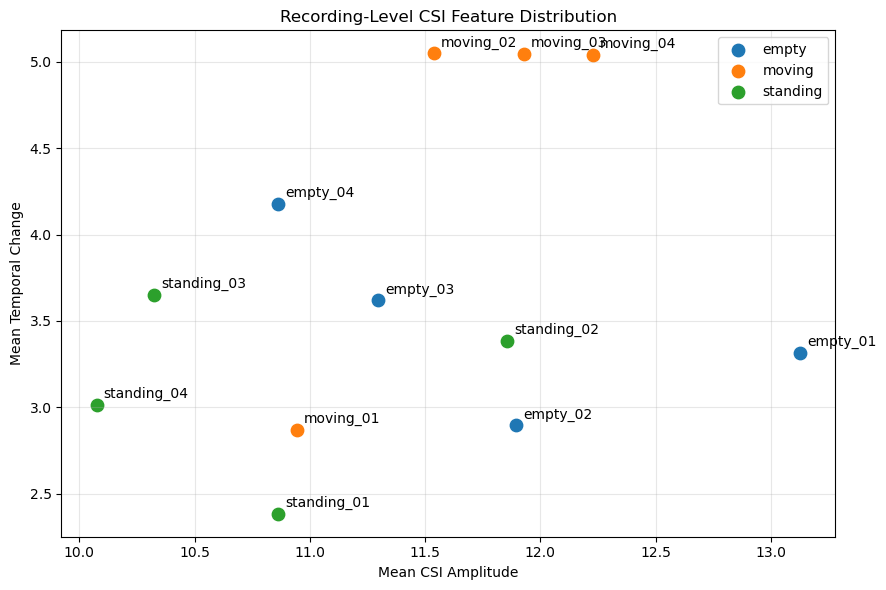

In [69]:
plt.figure(figsize=(9, 6))

for label in recording_stats_df["label"].unique():
    subset = recording_stats_df[
        recording_stats_df["label"] == label
    ]

    plt.scatter(
        subset["mean_amplitude"],
        subset["mean_temporal_change"],
        s=80,
        label=label
    )

    for _, row in subset.iterrows():
        plt.annotate(
            row["file"].replace(".csv", ""),
            (row["mean_amplitude"], row["mean_temporal_change"]),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.xlabel("Mean CSI Amplitude")
plt.ylabel("Mean Temporal Change")
plt.title("Recording-Level CSI Feature Distribution")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figure_csi_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 700x600 with 0 Axes>

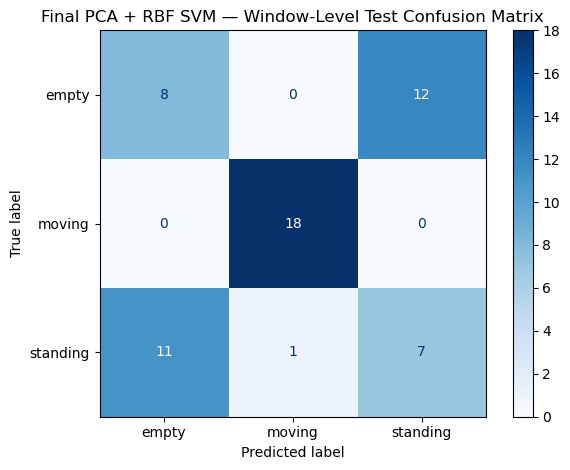

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Final PCA + RBF SVM — Window-Level Test Confusion Matrix")

plt.tight_layout()
plt.savefig(
    "figure_window_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 700x600 with 0 Axes>

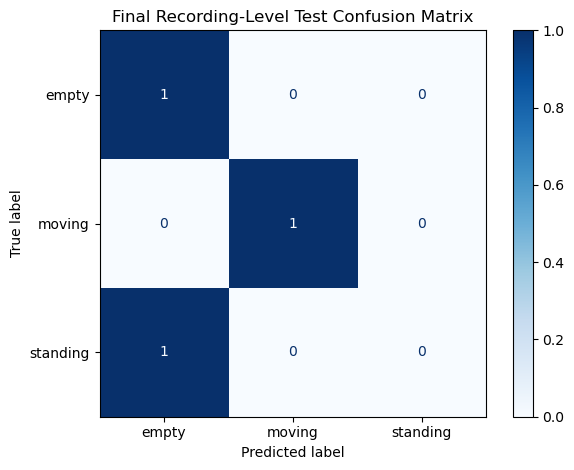

In [71]:
cm_recording = confusion_matrix(
    y_true_recording,
    y_pred_recording
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_recording,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Final Recording-Level Test Confusion Matrix")

plt.tight_layout()
plt.savefig(
    "figure_recording_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

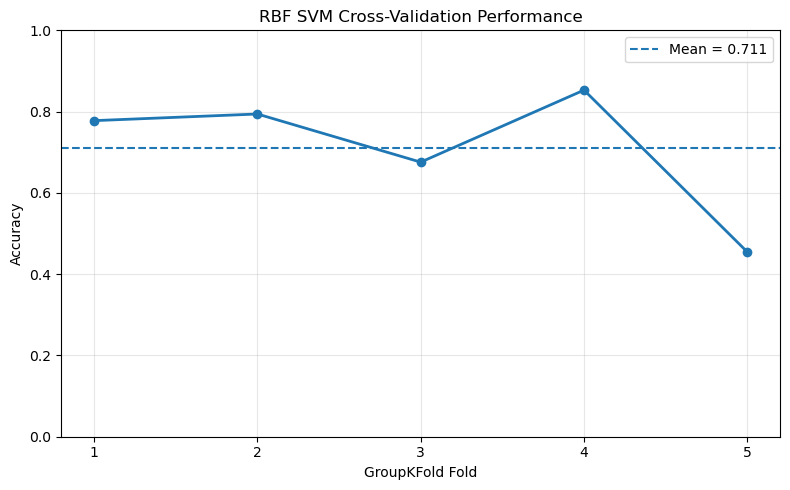

In [72]:
fold_cols = ["fold_1", "fold_2", "fold_3", "fold_4", "fold_5"]

fold_scores = [
    0.777778,
    0.794118,
    0.675676,
    0.852941,
    0.454545
]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    fold_scores,
    marker="o",
    linewidth=2
)

plt.axhline(
    np.mean(fold_scores),
    linestyle="--",
    label=f"Mean = {np.mean(fold_scores):.3f}"
)

plt.xlabel("GroupKFold Fold")
plt.ylabel("Accuracy")
plt.title("RBF SVM Cross-Validation Performance")

plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    "figure_cv_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()